In [1]:
%pip install                                                         \
        numpy                 matplotlib          matplotlib-inline  \
		ipython                                                      \
		sentencepiece         protobuf                               \
        sentence-transformers tiktoken            fastembed

%restart_python


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%restart_python` not found.


## 1. ライブラリのインポート

In [2]:
import gc
import numpy as np
import scipy as sp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data      import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Hiragino Sans'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

/Users/h_nagino/work/github/aiico_ai_agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.11.0 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0324 16:45:10.170000 4517 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


PyTorch version: 2.11.0
CUDA available: False
Using device: cpu


## 2. データの読み込み

In [3]:
SAMPLE_NUM = 100000

# --- cohort.npz の読み込み ---
# cohort.npz : ADID × コホートキャプション (L2正規化済みスパース行列)
cohort_path = "model/cohort.npz"
npz         = np.load(cohort_path, allow_pickle=True)

# スパース行列を再構築
np_cohort         = sp.sparse.csr_matrix((npz['data'], npz['indices'], npz['indptr']),shape=tuple(npz['shape']))
adid_list         = npz['adid_list']
business_codelist = npz['business_codelist']

# 大きすぎるため、処理量を制限
np_cohort = np_cohort[:SAMPLE_NUM]
adid_list = adid_list[:SAMPLE_NUM]

del npz
gc.collect()

print(f"コホート行列の形状 :        {np_cohort.shape}")
print(f"  - ADID数            : {np_cohort.shape[0]:,}")
print(f"  - コホートキャプション数 : {np_cohort.shape[1]:,}")
print(f"  - 非零要素数          : {np_cohort.nnz:,}")
print(f"  - 疎密度             : {np_cohort.nnz / (np_cohort.shape[0] * np_cohort.shape[1]):.6f}")

コホート行列の形状 :        (100000, 851)
  - ADID数            : 100,000
  - コホートキャプション数 : 851
  - 非零要素数          : 1,706,654
  - 疎密度             : 0.020055


In [21]:
# 商品リストは適宜書き換えること
product_list = ['&Face', 'メディキューブ', 'ワンバイコーセー', 'スパトリートメント', 'ボダナ', 'ヤーマン', 'ASTALIFT', 'ALBLANC', 'e-special', 'INFINITY', 'Exideal', 'ELECTRON', 'CREATE ION', 'SHISEIDO', 'SHISEIDO MEN', 'Dr.Ci:Labo', 'TWANY', 'HAKU', 'HOLISTIC', 'cures', 'エマーキット', 'REVITAL', 'REVITAL GRANAS', 'エリクシール', 'クレ・ド・ポー ボーテ', 'クレ・ド・ポー ボーテ シナクティフ', 'ベネフィーク', 'マキアージュ']
# model        = SentenceTransformer('BAAI/bge-m3')
model        = SentenceTransformer('cl-nagoya/ruri-v3-30m')
model.half()

lp_matrix    = model.encode(product_list, normalize_embeddings=True)  # キーワード数M × 1024

del model
gc.collect()

# 各種設定
ACTION_DIM = np_cohort.shape[1]
ITEM_DIM   = lp_matrix.shape[1]
EMBED_DIM  = 512
USER_NUM   = np_cohort.shape[0]
ITEM_NUM   = lp_matrix.shape[0]

# 教師データ
# user_click : ユーザー数 × 商品数
# ・ユーザーがクリックした商品     +1
# ・ユーザーがクリックしなかった商品 -1
user_click = (torch.rand(USER_NUM, ITEM_DIM) < 0.1).float()

print(f"\n次元設定:")
print(f"  USER_NUM (ユーザー数)    : {USER_NUM}")
print(f"  ACTION_DIM (行動ベクトル) : {ACTION_DIM}")
print(f"  ITEM_DIM (商品ベクトル)   : {ITEM_DIM}")
print(f"  EMBED_DIM (共通潜在空間)  : {EMBED_DIM}")
print(f"  SAMPLE_NUM (サンプル数)  : {SAMPLE_NUM}")

Loading weights: 100%|██████████| 62/62 [00:00<00:00, 16762.08it/s]



次元設定:
  USER_NUM (ユーザー数)    : 100000
  ACTION_DIM (行動ベクトル) : 851
  ITEM_DIM (商品ベクトル)   : 256
  EMBED_DIM (共通潜在空間)  : 512
  SAMPLE_NUM (サンプル数)  : 100000


In [35]:
def create_training_data(
    cohort_matrix : sp.sparse.csr_matrix,
    lp_matrix     : np.ndarray,
    click_matrix  : np.ndarray,
    num_samples   : int = 10000000,
    random_seed   : int = 42
):
    """
    コホート行列からTwo-Tower学習用のペアデータを生成する。

    正例: ユーザーがクリックした商品の組み合わせ
    負例: ユーザーがクリックしなかった商品の組み合わせ

    Returns:
        X_action : (N, ACTION_DIM) float32
        X_item   : (N, ITEM_DIM)   float32
        y        : (N,)            float32  {1.0, -1.0}
    """
    rng     = np.random.default_rng(random_seed)
    n_adids = cohort_matrix.shape[0]

    # サンプリングするADIDインデックス（行動が疎すぎるADIDを除外）
    row_nnz         = np.diff(cohort_matrix.indptr)  # 各ADIDの非零要素数
    active_mask     = row_nnz >= 3                   # 少なくとも3箇所訪問したADIDのみ
    active_adid_idx = np.where(active_mask)[0]
    print(f"アクティブADID数: {len(active_adid_idx):,} / {n_adids:,}")

    count       = 0
    X_action    = np.zeros((num_samples, ACTION_DIM), dtype=np.float32)
    X_item      = np.zeros((num_samples, ITEM_DIM),   dtype=np.float32)
    y           = np.zeros((num_samples, 2),          dtype=np.float32)
    sampled_idx = rng.permutation(active_adid_idx)
    for adid_i in sampled_idx:
        # ADIDの行動ベクトル（スパース行をdenseに変換）
        user_vec = np.asarray(cohort_matrix[adid_i].todense()).flatten().astype(np.float32)
        
        for item_i in range(ITEM_NUM):
            X_action[count] = user_vec
            X_item[count]   = lp_matrix[item_i]
            
            clicks          = click_matrix[adid_i, item_i]
            y[count, 0]     = clicks
            y[count, 0]     = 1 - clicks
            count           = count + 1
            
            if count >= num_samples: break
        if count >= num_samples: break

    return X_action, X_item, y


print("学習データを生成中...")

X_action, X_item, y = create_training_data(
    np_cohort,
    lp_matrix,
    user_click,
    num_samples=10000
)

print(f"\n生成結果:")
print(f"  X_action shape: {X_action.shape}")
print(f"  X_item   shape: {X_item.shape}")
print(f"  y        shape: {y.shape}")
print(f"  正例数: {(y == 1).sum():,}")
print(f"  負例数: {(y == 0).sum():,}")

学習データを生成中...
アクティブADID数: 75,618 / 100,000

生成結果:
  X_action shape: (10000, 851)
  X_item   shape: (10000, 256)
  y        shape: (10000, 2)
  正例数: 8,936
  負例数: 11,064


In [36]:
# Train/Val 分割（8:2）
split = int(len(y) * 0.8)

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

train_dataset = TensorDataset(to_tensor(X_action[:split]), to_tensor(X_item[:split]), to_tensor(y[:split]))
val_dataset   = TensorDataset(to_tensor(X_action[split:]), to_tensor(X_item[split:]), to_tensor(y[split:]))

BATCH_SIZE    = 256
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 32, Val batches: 8


## 4. Two-Tower モデルの定義

### アーキテクチャ

```
User Tower:  USER_DIM → 512 → 256 → EMBED_DIM(128) → L2正規化
Item Tower:  ITEM_DIM → 256 → 128 → EMBED_DIM(128) → L2正規化
Score = dot(u_embed, i_embed)  ← L2正規化済みなのでコサイン類似度と等価
```

### なぜTwoTowerか
- 行動ベクトル（`USER_DIM`次元）とLP係数ベクトル（`ITEM_DIM`次元）は**次元が異なる**ため直接の内積が不可
- 共通の128次元空間に射影することで数学的に正しいコサイン類似度を計算可能
- バッチ推論時にユーザー埋め込みとアイテム埋め込みを**独立に**事前計算できる（スケーラブル）

In [37]:
class TwoTowerModel(nn.Module):
    """ADID行動特徴と商品LP係数を共通の潜在空間に射影するTwo-Towerモデル。"""

    def __init__(self, action_dim:int, item_dim:int, embed_dim:int=128):
        super().__init__()

        # Action Tower: 行動ベクトル (ACTION_DIM → 1024 → 1024 → embed_dim)
        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, embed_dim),
        )

        # Item Tower: 商品ベクトル (ITEM_DIM → 1024 → 1024 → embed_dim)
        self.item_tower = nn.Sequential(
            nn.Linear(item_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, embed_dim),
        )

    def encode_user(self, action_features: torch.Tensor) -> torch.Tensor:
        """行動ベクトルをembed_dim次元に変換してL2正規化。"""
        a = self.action_tower(action_features)
        return nn.functional.normalize(a, p=2, dim=1)

    def encode_item(self, item_features: torch.Tensor) -> torch.Tensor:
        """LP係数ベクトルをembed_dim次元に変換してL2正規化。"""
        i = self.item_tower(item_features)
        return nn.functional.normalize(i, p=2, dim=1)

    def forward(self, action_features: torch.Tensor, item_features: torch.Tensor) -> torch.Tensor:
        a_embed = self.encode_user(action_features)
        i_embed = self.encode_item(item_features)
        # 内積 = L2正規化済みベクトルのコサイン類似度 (-1.0 ~ 1.0)
        inner   = torch.sum(a_embed * i_embed, dim=1)
        output  = (inner + 1) / 2
        return torch.stack([output, 1 - output], dim=1)


model = TwoTowerModel(action_dim=ACTION_DIM, item_dim=ITEM_DIM, embed_dim=EMBED_DIM).to(DEVICE)

# パラメータ数の確認
total_params = sum(p.numel() for p in model.parameters())
print(f"モデルパラメータ数: {total_params:,}")
print(f"\nAction Tower:")
print(model.action_tower)
print(f"\nItem Tower:")
print(model.item_tower)

モデルパラメータ数: 4,284,416

Action Tower:
Sequential(
  (0): Linear(in_features=851, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=1024, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1024, out_features=512, bias=True)
)

Item Tower:
Sequential(
  (0): Linear(in_features=256, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=1024, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1024, out_features=512, bias=True)
)


## 5. 損失関数と最適化手法

### CosineEmbeddingLoss vs MSELoss

| 損失関数 | 特徴 |
|---------|------|
| `MSELoss` | PDFベースラインと同じ。正例→1.0、負例→-1.0に引き寄せる |
| `CosineEmbeddingLoss` | PyTorch組み込みのコサイン損失。margin制御が可能 |

ここでは PDFベースラインに準拠して `MSELoss` を採用しつつ、`CosineEmbeddingLoss` も参考として示します。

In [38]:
EPOCHS = 50

# 損失関数
# criterion = nn.MSELoss()  # PDFベースライン準拠
criterion = nn.BCELoss()

# Adam optimizer + スケジューラ
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-5)
# optimizer = optim.RAdam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("損失関数: MSELoss")
print("最適化手法: AdamW (lr=1e-3, weight_decay=1e-5)")
print("スケジューラ: CosineAnnealingLR (patience=3)")

損失関数: MSELoss
最適化手法: AdamW (lr=1e-3, weight_decay=1e-5)
スケジューラ: CosineAnnealingLR (patience=3)


## 6. 学習ループ

In [39]:
def evaluate(model, loader, criterion, device):
    """検証データでのLoss・精度を計算。"""
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for batch_user, batch_item, batch_labels in loader:
            batch_user   = batch_user.to(device)
            batch_item   = batch_item.to(device)
            batch_labels = batch_labels.to(device)

            preds      = model(batch_user, batch_item)
            loss       = criterion(preds, batch_labels)
            total_loss += loss.item()

            # 精度: スコア>0 → 正例、スコア<0 → 負例
            pred_labels = torch.sign(preds)
            correct     += (pred_labels == batch_labels).sum().item()
            total       += len(batch_labels)

    return total_loss / len(loader), correct / total

train_losses, val_losses, val_accs = [], [], []

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Val Acc':>8} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    # --- 学習フェーズ ---
    model.train()
    total_train_loss = 0.0

    for batch_action, batch_item, batch_labels in train_loader:
        batch_action = batch_action.to(DEVICE)
        batch_item   = batch_item.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimizer.zero_grad()
        preds = model(batch_action, batch_item)
        loss  = criterion(preds, batch_labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # --- 検証フェーズ ---
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {avg_train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc:>8.4f} | {current_lr:>8.2e}")

print("\n学習完了！")

 Epoch | Train Loss |   Val Loss |  Val Acc |       LR
-------------------------------------------------------


/var/folders/xt/sjm9fswx5fsbx8zythb79vbm0000gp/T/ipykernel_4517/3120367335.py:52: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


     1 |     0.3640 |     0.2067 |   0.8980 | 1.00e-03
     2 |     0.2136 |     0.2015 |   0.8980 | 1.00e-03
     3 |     0.2101 |     0.2013 |   0.8980 | 1.00e-03
     4 |     0.2100 |     0.2013 |   0.8980 | 1.00e-03
     5 |     0.2094 |     0.2013 |   0.8980 | 1.00e-03
     6 |     0.2089 |     0.2012 |   0.8980 | 1.00e-03
     7 |     0.2088 |     0.2013 |   0.8980 | 1.00e-03
     8 |     0.2083 |     0.2012 |   0.8980 | 1.00e-03
     9 |     0.2082 |     0.2013 |   0.8980 | 1.00e-03
    10 |     0.2093 |     0.2013 |   0.8980 | 1.00e-03
    11 |     0.2082 |     0.2012 |   0.8980 | 1.00e-03
    12 |     0.2072 |     0.2013 |   0.8980 | 1.00e-03
    13 |     0.2083 |     0.2013 |   0.8980 | 1.00e-03
    14 |     0.2092 |     0.2012 |   0.8980 | 1.00e-03
    15 |     0.2108 |     0.2013 |   0.8980 | 1.00e-03
    16 |     0.2093 |     0.2013 |   0.8980 | 1.00e-03
    17 |     0.2092 |     0.2013 |   0.8980 | 1.00e-03
    18 |     0.2077 |     0.2014 |   0.8980 | 1.00e-03
    19 |  

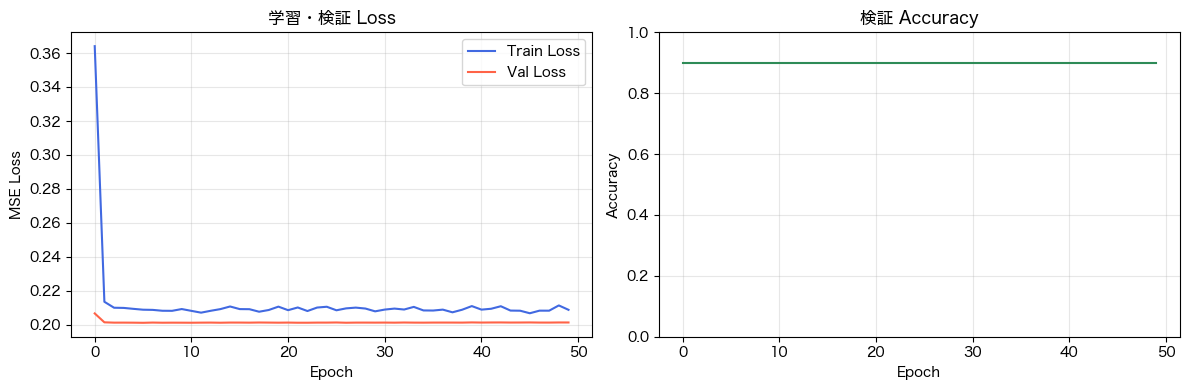

最終 Val Loss: 0.2014
最終 Val Acc:  0.8980


In [40]:
# 学習曲線の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='royalblue')
ax1.plot(val_losses,   label='Val Loss',   color='tomato')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('学習・検証 Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='seagreen')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('検証 Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('生成ファイル/two_tower_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"最終 Val Loss: {val_losses[-1]:.4f}")
print(f"最終 Val Acc:  {val_accs[-1]:.4f}")

## 7. スコア分布の確認

学習前（ランダム状態）と学習後でコサイン類似度の分布がどう変化したか確認します。

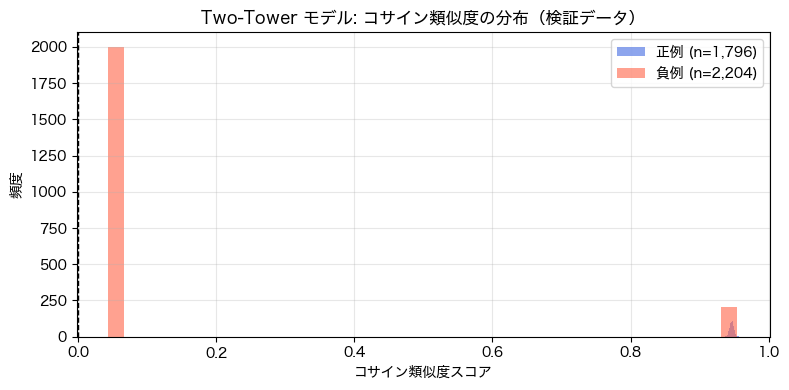

正例スコア: mean=0.9463, std=0.0030
負例スコア: mean=0.1363, std=0.2587
分離度 (正例mean - 負例mean): 0.8100


In [43]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_user, batch_item, batch_labels in val_loader:
        preds = model(batch_user.to(DEVICE), batch_item.to(DEVICE))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pos_scores = all_preds[all_labels == 1]
neg_scores = all_preds[all_labels == 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pos_scores, bins=40, alpha=0.6, color='royalblue', label=f'正例 (n={len(pos_scores):,})')
ax.hist(neg_scores, bins=40, alpha=0.6, color='tomato',    label=f'負例 (n={len(neg_scores):,})')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('コサイン類似度スコア')
ax.set_ylabel('頻度')
ax.set_title('Two-Tower モデル: コサイン類似度の分布（検証データ）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('生成ファイル/two_tower_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"正例スコア: mean={pos_scores.mean():.4f}, std={pos_scores.std():.4f}")
print(f"負例スコア: mean={neg_scores.mean():.4f}, std={neg_scores.std():.4f}")
print(f"分離度 (正例mean - 負例mean): {pos_scores.mean() - neg_scores.mean():.4f}")

## 8. モデルの保存と読み込み

In [44]:
import os

MODEL_PATH = "生成ファイル/two_tower_model.pt"

# 保存
torch.save({
    'model_state_dict': model.state_dict(),
    'action_dim': ACTION_DIM,
    'item_dim': ITEM_DIM,
    'embed_dim': EMBED_DIM,
    'val_loss': val_losses[-1],
    'val_acc': val_accs[-1],
}, MODEL_PATH)

print(f"モデル保存完了: {MODEL_PATH}")

# 読み込みテスト
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
loaded_model = TwoTowerModel(
    action_dim=checkpoint['action_dim'],
    item_dim=checkpoint['item_dim'],
    embed_dim=checkpoint['embed_dim']
)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print("モデル読み込み成功")
print(f"  保存時の Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  保存時の Val Acc:  {checkpoint['val_acc']:.4f}")

モデル保存完了: 生成ファイル/two_tower_model.pt
モデル読み込み成功
  保存時の Val Loss: 0.2014
  保存時の Val Acc:  0.8980
